# 人工提取 FDS 文本 vs 全部语料 词频比较

本脚本基于人工从两个 xlsx 文件中提取的 FDS 策略语句，与每个被试的全部 verbal content 进行配对比较：
- 数据来源：
  - 全部语料：`subject_utterances_game1style.csv`
  - 人工 FDS 语料：`without_obs_verbal_manual_retrieve.xlsx`、`with_obs_verbal_manual_retrieve.xlsx`
- 指标：探索词频率、对象维度词频率、属性维度词频率、总维度词频率
- 统计：Wilcoxon 符号秩检验（配对样本）
- 可视化：无色填充箱型 + 空心散点 + 配对连线


In [1]:
import re
import csv
import warnings
import os
import sys
from pathlib import Path

DEPENDENCY_DIR = Path(r'C:\Users\DELL\Documents\ChatGPT\不确定性探索\.notebook_deps_min')
if DEPENDENCY_DIR.is_dir() and str(DEPENDENCY_DIR) not in sys.path:
    sys.path.append(str(DEPENDENCY_DIR))

import jieba
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.unicode_minus'] = False

print('库导入完成')


库导入完成


In [2]:
# ============ 输入输出路径 ============
PROJECT_DIR = Path.cwd()  # Run from the package root
DATA_DIR = PROJECT_DIR / 'data' / 'interview_data'
DEFAULT_OUTPUT_DIR = PROJECT_DIR / 'figure2' / 'output'
OUTPUT_DIR = DEFAULT_OUTPUT_DIR.resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_ALL = DATA_DIR / 'subject_utterances_game1style.csv'
INPUT_MANUAL_FDS = [
    DATA_DIR / 'without_obs_verbal_manual_retrieve.xlsx',
    DATA_DIR / 'with_obs_verbal_manual_retrieve.xlsx',
]
OUT_METRICS = OUTPUT_DIR / 'game2_manual_fds_metrics0715.csv'

print(f'输入目录: {DATA_DIR}')
print(f'输出目录: {OUTPUT_DIR}')

# ============ 可视化参数 ============
DPI = 300
LABEL_SIZE = 16
TICK_SIZE = 12

COLOR_PT = '#D3D3D3'              # 散点颜色
COLOR_FDS_LABEL = '#E67E22'       # FDS 组标签颜色
COLOR_PAIR_LINE = '#D3D3D3'       # 配对连线颜色
COLOR_BOX = 'black'               # 箱型线条颜色
BOX_WIDTH = 0.25
BOX_LW = 1.8
AXIS_LW = 2.0
PT_SIZE = 22
PT_LW = 1.0

# ============ 文本预处理参数 ============
NUM_MAP = str.maketrans('0123456789', '零一二三四五六七八九')

STOPWORDS = set([
    '的', '了', '是', '我', '你', '他', '她', '它', '们', '这', '那', '我会', '和', '过',
    '也', '在', '有', '就', '不', '都', '说', '吧', '吗', '嗯', '啊', '哦', '呢', '嘛',
    '所以', '因为', '但是', '然后', '这个', '那个', '什么', '这样', '那样',
    '时候', '没有', '可能', '知道', '觉得', '发现', '进行', '认为', '以为',
    '后来', '开始', '的话', '对', '才', '把', '被', '会',
    '还', '就是', '想', '去', '要', '能', '得', '来', '做', '很', '最',
    '但', '到', '让', '给', '等', '挺', '跟', '与', '或', '及', '例如', '比如', '时',
    '是的', '好的', '行', 'OK', '主要', '其实', '首先', '之后', '之前', '后面', '当时',
    '大概', '差不多', '好像', '有点', '这种', '这些', '那种', '如果', '或者',
    '需要', '存在', '自己', '一直', '不太', '非常', '特别',
    '总共', '其他', '另外', '那么', '本身', '东西', '事情', '问题', '情况', '方式', '方法',
    # 高频口语/填充词（基于人工 FDS 文本词云分析补充）
    '一个', '两个', '三个', '四个', '五个', '六个',
    '一种', '两种', '三种', '四种',
    '一次', '一下', '一些', '一点',
    '比如说', '还有', '一样', '不是', '不同', '又', '相同', '还是', '是不是',
    '看', '喜欢', '高', '低', '大', '感觉',
    '应该', '更', '某', '尽量', '哪', '用', '刚',
    '每', '最后', '只', '每次', '可以', '里面', '下',
    '掉', '着', '找', '它们', '别的', '样子', '后期', '通过',
    '先', '再',
    # 第二轮补充（基于词云 top 词进一步过滤）
    '比较', '关注', '几个', '四张', '分', '方', '同一个', '很大', '说明', '以后',
    '到底', '出来', '左右', '肯定', '根据', '同时', '看看', '有没有', '先是', '对于',
    '出现', '他们', '并', '完全', '完', '判断', '带', '太', '怎么', '同样', '重要',
    '剩下', '包括', '不会', '每个', '其中',
])

# ============ 词表 ============
EXPLORE_WORDS = set([
    '尝试', '确定', '试', '排', '区分', '看到', '找到', '试试看', '选', '侧重', '对比', '考量',
    '挑选', '摸索', '聚焦', '锁定', '比较', '替换', '试出来', '比', '找出', '排除', '明确',
    '实验', '探索', '我试', '先试', '选择', '筛选', '排查', '观察', '试验', '发现', '推',
    '排查', '验证'
])

OBJECT_DIM_CANDIDATES = [
    '桌子', '桌', '桌面', '茶几', '地毯', '地垫', '植物', '盆栽', '绿植',
    '花', '花朵', '花儿', '挂画', '画', '画儿', '墙画', '壁画', '沙发', '植被'
]

ATTR_DIM_CANDIDATES = [
    '类别', '种类', '颜色', '类型', '款式', '样式', '内容', '材质', '纹理',
    '图案', '花纹', '形状', '元素', '因素', '色彩'
]

OBJECT_DIM_SET = set(OBJECT_DIM_CANDIDATES)
ATTR_DIM_SET = set(ATTR_DIM_CANDIDATES)
DIM_SET = OBJECT_DIM_SET | ATTR_DIM_SET

print('词表配置完成')
print(f'探索词：{len(EXPLORE_WORDS)} 个')
print(f'对象维度词：{len(OBJECT_DIM_SET)} 个')
print(f'属性维度词：{len(ATTR_DIM_SET)} 个')
print(f'总维度词：{len(DIM_SET)} 个')


输入目录: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\data\interview_data
输出目录: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3
词表配置完成
探索词：35 个
对象维度词：19 个
属性维度词：15 个
总维度词：34 个


In [3]:
def clean_text(text):
    """
    文本清理：
    1. 将阿拉伯数字逐位替换为中文数字。
    2. 归一化空白字符。
    """
    if not text:
        return ''
    text = str(text).translate(NUM_MAP)
    # 去除标点符号（保留中文/英文/数字字符及空白，用于后续分词）
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text):
    """
    分词并去停用词。
    不过滤单字词；去除纯标点、纯英文、纯数字（含中文数字）token。
    """
    if not text:
        return []
    tokens = []
    for t in jieba.cut(text):
        t = t.strip()
        if not t:
            continue
        if t in STOPWORDS:
            continue
        # 过滤纯标点
        if re.match(r'^[^\w\s]+$', t):
            continue
        # 过滤纯英文
        if re.match(r'^[a-zA-Z]+$', t):
            continue
        # 过滤纯数字（含中文数字）
        if re.match(r'^[0-9零一二三四五六七八九十百千万]+$', t):
            continue
        tokens.append(t)
    return tokens


def make_ngrams(tokens, max_n=3):
    """生成 token n-gram 列表，用于多词匹配。"""
    ngrams = []
    upper = min(max_n, len(tokens))
    for n in range(1, upper + 1):
        for i in range(len(tokens) - n + 1):
            ngrams.append(''.join(tokens[i:i + n]))
    return ngrams


def count_vocab(tokens, vocab_set, max_n=3):
    """
    统计 token n-gram 中属于 vocab_set 的次数。
    返回 frequency = 命中次数 / token 总数。
    """
    ngrams = make_ngrams(tokens, max_n)
    matched = [ng for ng in ngrams if ng in vocab_set]
    total = len(tokens)
    freq = len(matched) / total if total > 0 else 0.0
    return freq


print('预处理函数定义完成')


预处理函数定义完成


In [4]:
# ---------- 1. 读取全部语料 ----------
df_all = pd.read_csv(INPUT_ALL, encoding='utf-8-sig')
content_cols = [c for c in df_all.columns if c.startswith('verbal_content')]

all_verbal = {}
for _, row in df_all.iterrows():
    sid = str(row['subject_id']).strip()
    parts = [clean_text(row[c]) for c in content_cols
             if pd.notna(row[c]) and str(row[c]).strip()]
    all_verbal[sid] = ' '.join(parts)

print(f'全部语料：{len(all_verbal)} 名被试')

# ---------- 2. 读取人工提取的 FDS 语料 ----------
def normalize_sid(sid_raw):
    """提取被试编号前 8 位数字；若无法提取则返回 None。"""
    sid_str = str(sid_raw).strip()
    m = re.match(r'(\d{8})', sid_str)
    return m.group(1) if m else None


def find_fds_col(columns):
    """查找包含 'FDS' 和 '策略' 的列名。"""
    for c in columns:
        c_str = str(c)
        if 'FDS' in c_str and '策略' in c_str:
            return c
    return None


fds_verbal = {}
for f in INPUT_MANUAL_FDS:
    dfx = pd.read_excel(f)
    sid_col = dfx.columns[0]
    fds_col = find_fds_col(dfx.columns)
    if fds_col is None:
        raise ValueError(f'在 {f} 中未找到 FDS策略 列')

    n_added = 0
    for _, row in dfx.iterrows():
        sid = normalize_sid(row[sid_col])
        if sid is None or sid not in all_verbal:
            continue
        text = clean_text(row[fds_col]) if pd.notna(row[fds_col]) else ''
        fds_verbal[sid] = text
        n_added += 1
    print(f'{f}: 匹配 {n_added} 名被试')

print(f'人工 FDS 语料：{len(fds_verbal)} 名被试')


全部语料：92 名被试
C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\data\interview_data\without_obs_verbal_manual_retrieve.xlsx: 匹配 37 名被试
C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\data\interview_data\with_obs_verbal_manual_retrieve.xlsx: 匹配 35 名被试
人工 FDS 语料：72 名被试


In [5]:
metrics = []
for sid in sorted(fds_verbal.keys()):
    all_tokens = tokenize(all_verbal[sid])
    fds_tokens = tokenize(fds_verbal[sid])

    metrics.append({
        'subject_id': sid,
        'all_n_tokens': len(all_tokens),
        'fds_n_tokens': len(fds_tokens),
        # 全部语料指标
        'explore_frequency_all': count_vocab(all_tokens, EXPLORE_WORDS),
        'object_dim_frequency_all': count_vocab(all_tokens, OBJECT_DIM_SET),
        'attr_dim_frequency_all': count_vocab(all_tokens, ATTR_DIM_SET),
        'dim_frequency_all': count_vocab(all_tokens, DIM_SET),
        # 人工 FDS 语料指标
        'explore_frequency_fds': count_vocab(fds_tokens, EXPLORE_WORDS),
        'object_dim_frequency_fds': count_vocab(fds_tokens, OBJECT_DIM_SET),
        'attr_dim_frequency_fds': count_vocab(fds_tokens, ATTR_DIM_SET),
        'dim_frequency_fds': count_vocab(fds_tokens, DIM_SET),
        'fds_text': fds_verbal[sid],
    })

freq_df = pd.DataFrame(metrics)
print(freq_df.head())
print(f'\n共 {len(freq_df)} 名被试的指标已计算')


Building prefix dict from the default dictionary ...


Loading model from cache C:\Users\DELL\AppData\Local\Temp\jieba.cache


Loading model cost 0.357 seconds.


Prefix dict has been built successfully.


  subject_id  all_n_tokens  fds_n_tokens  explore_frequency_all  \
0   26050801           438            40               0.075342   
1   26050901            96            25               0.031250   
2   26050902           213            21               0.061033   
3   26050903           102            17               0.147059   
4   26051101           351            41               0.119658   

   object_dim_frequency_all  attr_dim_frequency_all  dim_frequency_all  \
0                  0.100457                0.038813           0.139269   
1                  0.187500                0.104167           0.291667   
2                  0.169014                0.028169           0.197183   
3                  0.176471                0.029412           0.205882   
4                  0.108262                0.042735           0.150997   

   explore_frequency_fds  object_dim_frequency_fds  attr_dim_frequency_fds  \
0               0.075000                  0.000000                0.000000

In [6]:
freq_df.to_csv(OUT_METRICS, index=False, encoding='utf-8-sig')
print(f'已保存 {OUT_METRICS}')


已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_metrics0715.csv


In [7]:
def wilcoxon_report(col_fds, col_all):
    y_fds = freq_df[col_fds].values
    y_all = freq_df[col_all].values
    stat, p = stats.wilcoxon(y_fds, y_all, zero_method='zsplit')
    mean_fds = np.mean(y_fds)
    mean_all = np.mean(y_all)
    return {
        'fds_mean': mean_fds,
        'all_mean': mean_all,
        'statistic': stat,
        'p_value': p,
        'sig': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    }


comparisons = [
    ('dim_frequency_fds', 'dim_frequency_all', '总维度词频率'),
    ('explore_frequency_fds', 'explore_frequency_all', '探索词频率'),
    ('object_dim_frequency_fds', 'object_dim_frequency_all', '对象维度词频率'),
    ('attr_dim_frequency_fds', 'attr_dim_frequency_all', '属性维度词频率'),
]

print('Wilcoxon 符号秩检验结果（FDS vs All）：')
print('-' * 70)
for col_fds, col_all, label in comparisons:
    r = wilcoxon_report(col_fds, col_all)
    print(f'{label:20s}  FDS mean={r["fds_mean"]:.4f}  All mean={r["all_mean"]:.4f}  '
          f'W={r["statistic"]:.1f}  p={r["p_value"]:.4g}  {r["sig"]}')


Wilcoxon 符号秩检验结果（FDS vs All）：
----------------------------------------------------------------------
总维度词频率                FDS mean=0.2381  All mean=0.1808  W=657.0  p=0.000227  ***
探索词频率                 FDS mean=0.1234  All mean=0.0765  W=591.0  p=4.965e-05  ***
对象维度词频率               FDS mean=0.1494  All mean=0.1156  W=731.5  p=0.00108  **
属性维度词频率               FDS mean=0.0887  All mean=0.0652  W=831.5  p=0.006776  **


In [8]:
def plot_paired_box(col_fds, col_all, ylabel, ylim, outname):
    fig, ax = plt.subplots(figsize=(3.7, 3.3))

    y_a = freq_df[col_fds].values
    y_b = freq_df[col_all].values
    mask = ~(np.isnan(y_a) | np.isnan(y_b))
    y_a, y_b = y_a[mask], y_b[mask]
    n = len(y_a)

    # 样式参数（与 3 组图参考代码对齐）
    tick_width = 1.6
    tick_length = 6
    xtick_fontsize = TICK_SIZE
    ytick_fontsize = TICK_SIZE
    ylabel_fontsize = LABEL_SIZE

    # 箱型图（置于最上层）
    bp = ax.boxplot([y_a, y_b], positions=[1, 2], widths=BOX_WIDTH, patch_artist=True,
                    boxprops=dict(linewidth=BOX_LW, zorder=3),
                    medianprops=dict(linewidth=BOX_LW, zorder=3),
                    whiskerprops=dict(linewidth=BOX_LW, zorder=3),
                    capprops=dict(linewidth=BOX_LW, zorder=3),
                    flierprops=dict(marker='none'))

    # FDS: 填充 #8657BE，黑色边框，紫色须线/帽，黑色中线
    # All: 白色填充，#8657BE 边框/须线/帽/中线
    bp['boxes'][0].set_facecolor('#8657BE')
    bp['boxes'][0].set_edgecolor(COLOR_BOX)
    bp['medians'][0].set_color(COLOR_BOX)
    bp['boxes'][1].set_facecolor('white')
    bp['boxes'][1].set_edgecolor('#8657BE')
    bp['medians'][1].set_color('#8657BE')
    for i in range(2):
        line_color = '#8657BE'
        bp['whiskers'][2 * i].set_color(line_color)
        bp['whiskers'][2 * i + 1].set_color(line_color)
        bp['caps'][2 * i].set_color(line_color)
        bp['caps'][2 * i + 1].set_color(line_color)
    for element in ['boxes', 'whiskers', 'caps', 'medians']:
        plt.setp(bp[element], zorder=3)

    # 根据箱线图上分位数线（whisker cap）自动调整 ylim 上界
    cap_ys = [cap.get_ydata()[0] for cap in bp['caps']]
    upper_whisker = max(cap_ys) if cap_ys else max(np.max(y_a), np.max(y_b))
    y_lower_base = ylim[0] if ylim is not None else min(np.min(y_a), np.min(y_b))
    padded_top = upper_whisker + 0.08 * (upper_whisker - y_lower_base)

    # Wilcoxon 配对检验
    if n > 1:
        stat, p = stats.wilcoxon(y_a, y_b, zero_method='zsplit')
    else:
        p = np.nan

    # y 轴刻度：生成约 4 个 nice ticks，并保证最小/最大刻度位于 y 轴两端
    if ylim is not None:
        y_min, y_max = ylim
        y_max = max(y_max, padded_top)
    else:
        y_min = min(np.min(y_a), np.min(y_b))
        y_max = padded_top

    import matplotlib.ticker as mticker
    locator = mticker.MaxNLocator(nbins=4)
    all_ticks = locator.tick_values(y_min, y_max)
    if len(all_ticks) < 2:
        all_ticks = [y_min, y_max]
    step = all_ticks[1] - all_ticks[0]

    tick_min = all_ticks[all_ticks <= y_min][-1] if np.any(all_ticks <= y_min) else y_min
    tick_max = all_ticks[all_ticks >= y_max][0] if np.any(all_ticks >= y_max) else y_max
    while tick_max < padded_top:
        tick_max += step

    ticks = np.arange(tick_min, tick_max + step / 2, step)
    ax.set_yticks(ticks)
    ax.set_ylim(tick_min, tick_max)

    # ylabel 中可包含换行符 \n 手动换行，例如 'Dimension\nWord Frequency'
    ax.set_ylabel(ylabel, fontsize=ylabel_fontsize, fontweight='bold',
                  rotation=90, ha='center', va='center', labelpad=28)

    # ---------- 参考 3 组图的 x/y 轴样式 ----------
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(AXIS_LW)
    ax.spines['bottom'].set_linewidth(tick_width)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 10))

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(
        axis='x',
        labelsize=xtick_fontsize,
        direction='out',
        bottom=True,
        top=False,
        length=tick_length,
        width=tick_width,
        pad=12
    )
    ax.tick_params(
        axis='y',
        labelsize=ytick_fontsize,
        direction='out',
        left=True,
        right=False,
        length=tick_length,
        width=tick_width,
        pad=4
    )
    # ---------------------------------------------

    ax.set_xlim(0.5, 2.5)

    # x 轴刻度与标签
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        ['DIS\nCorpus', 'Full\nCorpus'],
        fontsize=ylabel_fontsize,
        rotation=0,
        ha='center',
        fontweight='bold'
    )

    # 底部 spine 只覆盖两个箱体之间
    ax.spines['bottom'].set_bounds(1, 2)

    # 显著性括号（线粗与箱体一致）
    if p < 0.05 and p == p:
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        y_min, y_max = ax.get_ylim()
        h = 0.04 * (y_max - y_min)
        y = y_max - 0.06 * (y_max - y_min)
        ax.plot([1, 1, 2, 2], [y - h, y, y, y - h],
                color='black', linewidth=BOX_LW, solid_capstyle='round', zorder=4)
        ax.text(1.5, y + 0.01 * (y_max - y_min), sig,
                ha='center', va='bottom', fontsize=TICK_SIZE + 2,
                fontweight='bold', zorder=4)

    plt.tight_layout()
    outpath = OUTPUT_DIR / outname
    plt.savefig(outpath, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'已保存 {outpath}; n={n}; Wilcoxon p={p:.6g}')


print('绘图函数定义完成')


绘图函数定义完成


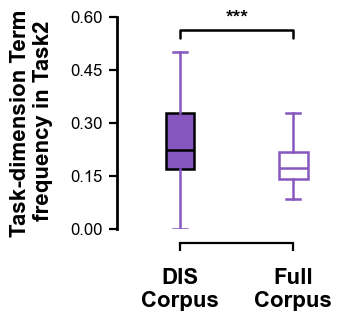

已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_vs_all_boxplot_totaldim.png; n=72; Wilcoxon p=0.000227018


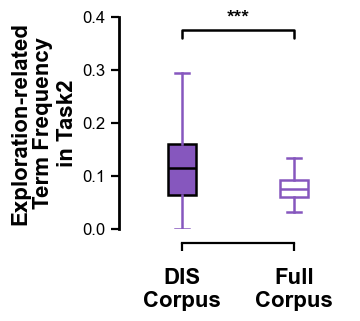

已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_vs_all_boxplot_explore.png; n=72; Wilcoxon p=4.9653e-05


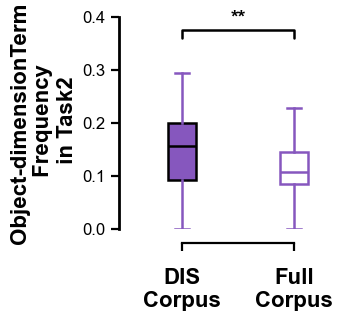

已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_vs_all_boxplot_objectdim.png; n=72; Wilcoxon p=0.00108


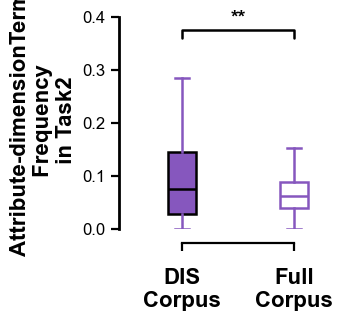

已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_vs_all_boxplot_attrdim.png; n=72; Wilcoxon p=0.00677631

四张箱型图已保存至 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3


In [9]:
plot_comparisons = [
    ('dim_frequency_fds', 'dim_frequency_all', 'Task-dimension Term\n frequency in Task2',
     (0, 0.6), 'game2_manual_fds_vs_all_boxplot_totaldim.png'),
    ('explore_frequency_fds', 'explore_frequency_all', 'Exploration-related\nTerm Frequency\nin Task2',
     (0, 0.35), 'game2_manual_fds_vs_all_boxplot_explore.png'),
    ('object_dim_frequency_fds', 'object_dim_frequency_all', 'Object-dimensionTerm\n Frequency\n in Task2',
     (0, 0.35), 'game2_manual_fds_vs_all_boxplot_objectdim.png'),
    ('attr_dim_frequency_fds', 'attr_dim_frequency_all', 'Attribute-dimensionTerm\n Frequency\n in Task2',
     (0, 0.35), 'game2_manual_fds_vs_all_boxplot_attrdim.png'),
]

for col_a, col_b, ylabel, ylim, outname in plot_comparisons:
    plot_paired_box(col_a, col_b, ylabel, ylim, outname)

print(f'\n四张箱型图已保存至 {OUTPUT_DIR}')


## 人工 FDS 策略文本词云分析

对成功匹配的 72 名被试的人工提取 FDS 策略文本进行分词、去停用词后，绘制高频词词云图。


词云使用字体: C:/Windows/Fonts/simhei.ttf
人工 FDS 策略文本总词数（去停用词后）: 2178
不同词汇总数: 650

频率最高的前 50 个词汇：
  沙发: 133
  颜色: 112
  选: 81
  选择: 49
  分数: 48
  粉色: 45
  绿色: 38
  茶几: 37
  桌子: 35
  地毯: 34
  壁画: 33
  圆形: 30
  试: 29
  元素: 25
  植物: 24
  排除: 22
  评分: 22
  确定: 20
  因素: 20
  花: 19
  蓝色: 17
  影响: 17
  图片: 17
  得分: 16
  尝试: 14
  形状: 12
  策略: 12
  黄色: 12
  图案: 12
  固定: 11
  圆: 10
  特征: 9
  深色: 9
  画: 9
  顾客: 9
  最高: 9
  筛选: 9
  排列组合: 8
  组合: 8
  选项: 8
  保持: 8
  台灯: 8
  款式: 8
  绿: 8
  方案: 8
  棕色: 8
  全部: 8
  墩子: 8
  测试: 7
  大理石: 7


已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_wordcloud_chinese.png


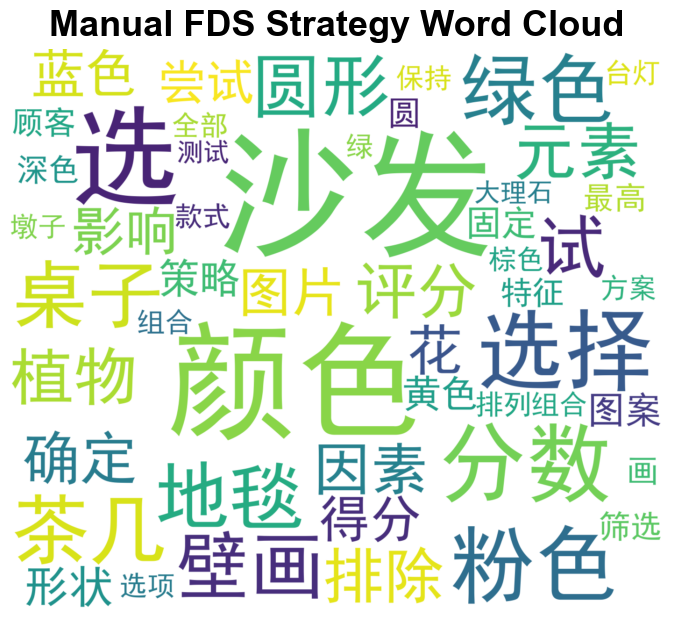

In [10]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.font_manager as fm

# 可调参数
TOP_N_WORDS = 50
WC_WIDTH = 700
WC_HEIGHT = 600
WC_BG_COLOR = 'white'
WC_COLLOCATION_THRESHOLD = 10

# 选择支持中文的字体
font_candidates = [
    'C:/Windows/Fonts/simhei.ttf',
    'C:/Windows/Fonts/msyh.ttc',
    'C:/Windows/Fonts/simsun.ttc',
    'C:/Windows/Fonts/arialuni.ttf',
]
wc_font_path = None
for fp in font_candidates:
    if Path(fp).exists():
        wc_font_path = fp
        break
if wc_font_path is None:
    available = [f.fname for f in fm.fontManager.ttflist
                 if 'CJK' in f.name or 'Hei' in f.name or 'YaHei' in f.name]
    if available:
        wc_font_path = available[0]
    else:
        raise FileNotFoundError('未找到支持中文的字体，请手动指定 wc_font_path')
print(f'词云使用字体: {wc_font_path}')

# 收集人工 FDS 策略文本中的所有词（使用 notebook 中已定义的 clean_text + tokenize）
all_manual_words = []
for text in freq_df['fds_text'].dropna():
    words = tokenize(clean_text(str(text)))
    all_manual_words.extend(words)

# 统计词频并取 TOP_N
word_counter = Counter(all_manual_words)
top_words = dict(word_counter.most_common(TOP_N_WORDS))

print(f'人工 FDS 策略文本总词数（去停用词后）: {len(all_manual_words)}')
print(f'不同词汇总数: {len(word_counter)}')
print()
print(f'频率最高的前 {TOP_N_WORDS} 个词汇：')
for w, c in word_counter.most_common(TOP_N_WORDS):
    print(f'  {w}: {c}')

# 生成词云
wc = WordCloud(
    font_path=wc_font_path,
    width=WC_WIDTH,
    height=WC_HEIGHT,
    background_color=WC_BG_COLOR,
    max_words=TOP_N_WORDS,
    collocation_threshold=WC_COLLOCATION_THRESHOLD,
    prefer_horizontal=1.0,
    min_font_size=10,
    max_font_size=150,
    relative_scaling=0.5,
    margin=1,
    scale=2,
).generate_from_frequencies(top_words)

# 绘制词云图
fig, ax = plt.subplots(figsize=(WC_WIDTH / 100, WC_HEIGHT / 100), dpi=100)
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Manual FDS Strategy Word Cloud',
             fontsize=LABEL_SIZE + 10, fontweight='bold', pad=10)
plt.tight_layout(pad=0)
wordcloud_cn_path = OUTPUT_DIR / 'game2_manual_fds_wordcloud_chinese.png'
plt.savefig(wordcloud_cn_path, dpi=DPI, bbox_inches='tight', facecolor='white')
print(f'已保存 {wordcloud_cn_path}')
plt.show()



人工 FDS 策略文本总词数（映射为英文后）: 1280
不同英文词汇总数: 88
未映射词汇总数: 898

频率最高的前 50 个英文词汇：
  sofa: 133
  select: 130
  color: 112
  score: 86
  attempt: 47
  green: 46
  round: 45
  pink: 45
  painting: 42
  coffee table: 37
  table: 35
  carpet: 34
  element: 25
  plant: 24
  exclude: 23
  determine: 20
  factor: 20
  flower: 19
  blue: 17
  influence: 17
  image: 17
  combination: 14
  shape: 12
  strategy: 12
  yellow: 12
  pattern: 12
  fixed: 11
  feature: 9
  dark color: 9
  customer: 9
  highest: 9
  filter: 9
  permutation combination: 8
  option: 8
  keep: 8
  table_lamp: 8
  style: 8
  plan: 8
  brown: 8
  all: 8
  stool: 8
  test: 7
  marble: 7
  guess: 7
  preference: 7
  result: 5
  first round: 5
  whole: 4
  many: 4
  see: 3

出现次数最多的前 20 个未映射词汇（供补充字典参考）：
  石头: 7
  图: 6
  不变: 6
  点: 6
  所有: 6
  花儿: 6
  反正: 6
  变量: 6
  儿: 6
  喜好: 6
  控制变量: 6
  方形: 6
  白色: 6
  里边: 6
  单一: 5
  高分: 5
  类型: 5
  浅色: 5
  去试: 5
  我先: 4
  对比: 4
  全选: 4
  种: 4
  第一次: 4
  挑选: 4
  我刚: 4
  黄: 4
  中间: 4
  四类: 4
  个: 4
 

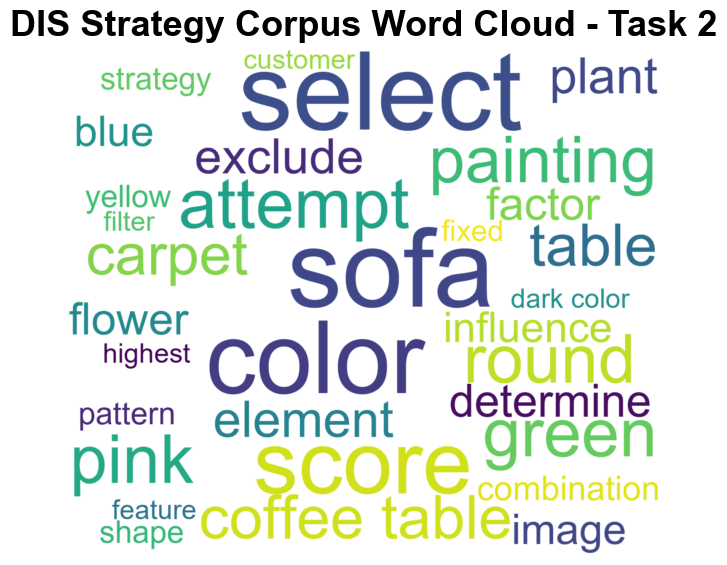


英文词云图已保存至: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_manual_fds_wordcloud_english.png


In [11]:
# ===================== 人工 FDS 策略文本英文词云分析 =====================
# 将中文词汇映射为英文后生成词云；若多个中文词对应同一英文词，则合并计数。
from wordcloud import WordCloud
from collections import Counter

# 中文词 -> 英文词映射字典（可根据需要补充/修改）
CN_TO_EN = {
    # ---- 家具/任务相关具体词汇 ----
    '沙发': 'sofa',
    '茶几': 'coffee table',
    '地毯': 'carpet',
    '壁画': 'painting',
    '画': 'painting',
    '台灯': 'table_lamp',
    '桌子': 'table',
    '墩子': 'stool',
    '大理石': 'marble',
    '植物': 'plant',
    '花': 'flower',
    # ---- 颜色/外观属性 ----
    '颜色': 'color',
    '粉色': 'pink',
    '绿色': 'green',
    '绿': 'green',
    '蓝色': 'blue',
    '黄色': 'yellow',
    '棕色': 'brown',
    '深色': 'dark color',
    '形状': 'shape',
    '圆形': 'round',
    '圆': 'round',
    '图案': 'pattern',
    '款式': 'style',
    '特征': 'feature',
    '大小': 'size',
    # ---- 任务/评估/策略相关 ----
    '分数': 'score',
    '评分': 'score',
    '得分': 'score',
    '分': 'score',
    '高': 'high',
    '最高': 'highest',
    '更高': 'higher',
    '选择': 'select',
    '选': 'select',
    '选项': 'option',
    '确定': 'determine',
    '找出': 'find',
    '找到': 'find',
    '看到': 'see',
    '发现': 'find',
    '排除': 'exclude',
    '排': 'exclude',
    '放在': 'put',
    '放': 'put',
    '摆放': 'put',
    '摆': 'put',
    '排放': 'put',
    '位置': 'position',
    '排列组合': 'permutation combination',
    '组合': 'combination',
    '搭配': 'combination',
    '筛选': 'filter',
    '固定': 'fixed',
    '保持': 'keep',
    '方案': 'plan',
    '策略': 'strategy',
    '模式': 'pattern',
    '方法': 'method',
    '方式': 'way',
    '重要': 'important',
    '影响': 'influence',
    '元素': 'element',
    '因素': 'factor',
    '图片': 'image',
    '顾客': 'customer',
    '全部': 'all',
    # ---- 过程/逻辑/通用词 ----
    '尝试': 'attempt',
    '试': 'attempt',
    '试出来': 'attempt',
    '测试': 'test',
    '实验': 'test',
    '相同': 'same',
    '一样': 'same',
    '同一个': 'same',
    '同一种': 'same',
    '同一': 'same',
    '三个': 'three',
    '三个一样': 'three same',
    '三个相同': 'three same',
    '三个都是': 'three same',
    '两个': 'two',
    '先': 'first',
    '第一步': 'first step',
    '第二步': 'second step',
    '第三步': 'third step',
    '先放': 'first put',
    '再放': 'then put',
    '依次': 'in order',
    '逐个': 'one by one',
    '每次': 'each time',
    '每轮': 'each round',
    '轮流': 'rotate',
    '循环': 'cycle',
    '重复': 'repeat',
    '规律': 'rule',
    '喜欢': 'like',
    '偏好': 'preference',
    '权重': 'weight',
    '不同': 'different',
    '差异': 'difference',
    '最后': 'last',
    '最终': 'final',
    '结果': 'result',
    '后': 'after',
    '中': 'middle',
    '里': 'inside',
    '更': 'more',
    '比较': 'compare',
    '比': 'compare',
    '按': 'by',
    '根据': 'according to',
    '依据': 'according to',
    '第一局': 'first round',
    '第一轮': 'first round',
    '一局': 'round',
    '一轮': 'round',
    '游戏': 'game',
    '物品': 'item',
    '东西': 'item',
    '感觉': 'feel',
    '觉得': 'feel',
    '认为': 'think',
    '知道': 'know',
    '猜想': 'guess',
    '猜': 'guess',
    '验证': 'verify',
    '明确': 'clarify',
    '观察': 'observe',
    '记忆': 'remember',
    '记住': 'remember',
    '回忆': 'recall',
    '多': 'many',
    '少': 'few',
    '大': 'big',
    '小': 'small',
    '上': 'up',
    '下': 'down',
    '前': 'front',
    '左': 'left',
    '右': 'right',
    '之间': 'between',
    '和': 'and',
    '或': 'or',
    '不是': 'not',
    '没有': 'none',
    '不': 'no',
    '就': 'then',
    '再': 'again',
    '又': 'again',
    '可以': 'can',
    '可能': 'maybe',
    '应该': 'should',
    '一定': 'must',
    '会': 'will',
    '哪个': 'which',
    '什么': 'what',
    '怎么': 'how',
    '为什么': 'why',
    '开始': 'start',
    '结束': 'end',
    '过程': 'process',
    '步骤': 'step',
    '阶段': 'stage',
    '整体': 'whole',
    '部分': 'part',
    '一半': 'half',
    '另一半': 'other half',
    '分别': 'respectively',
    '各自': 'respectively',
    '对应': 'correspond',
    '匹配': 'match',
    '错误': 'wrong',
    '正确': 'right',
    '对': 'right',
    '错': 'wrong',
    '成功': 'success',
    '失败': 'failure',
    '优化': 'optimize',
    '改进': 'improve',
    '提高': 'improve',
    '降低': 'reduce',
    '减少': 'reduce',
    '增加': 'increase',
    '尽量': 'as much as possible',
    '尽可能': 'as much as possible',
    '随机': 'random',
    '任意': 'arbitrary',
    '特意': 'specially',
    '专门': 'specially',
    '清楚': 'clear',
    '明显': 'obvious',
    '简单': 'simple',
    '容易': 'easy',
    '难': 'difficult',
    '复杂': 'complex',
    '变化': 'change',
    '变动': 'change',
    '变成': 'become',
    '转为': 'turn',
    '直接': 'direct',
    '间接': 'indirect',
    '快速': 'fast',
    '慢': 'slow',
    '同时': 'meanwhile',
    '一起': 'together',
    '假设': 'hypothesis',
    '推断': 'infer',
    '推理': 'reasoning',
    '逻辑': 'logic',
    '概率': 'probability',
    '几率': 'probability',
    '可能性': 'possibility',
    '信息': 'information',
    '线索': 'clue',
    '提示': 'hint',
    '反馈': 'feedback',
    '规则': 'rule',
    '条件': 'condition',
    '限制': 'constraint',
    '约束': 'constraint',
    '目标': 'goal',
    '目的': 'purpose',
    '意图': 'intention',
    '计划': 'plan',
    '执行': 'execute',
    '实施': 'implement',
    '操作': 'operation',
    '点击': 'click',
    '放置': 'place',
    '拖': 'drag',
    '移动': 'move',
    '交换': 'exchange',
    '记录': 'record',
    '列表': 'list',
    '表格': 'table',
    '矩阵': 'matrix',
    '数量': 'quantity',
    '数目': 'quantity',
    '一共': 'total',
    '总共': 'total',
    '合计': 'total',
}

# 收集人工 FDS 策略文本中的所有词，并映射为英文
all_manual_en_words = []
unmapped_words = []
for text in freq_df['fds_text'].dropna():
    words = tokenize(clean_text(str(text)))
    for w in words:
        if not w or w.isspace():
            continue
        en = CN_TO_EN.get(w)
        if en:
            all_manual_en_words.append(en)
        else:
            # 未在字典中映射的词保留原中文（便于检查），不参与英文合并
            unmapped_words.append(w)

# 合并相同英文词的计数
en_word_counter = Counter(all_manual_en_words)
top_en_words = dict(en_word_counter.most_common(TOP_N_WORDS))

print(f'人工 FDS 策略文本总词数（映射为英文后）: {len(all_manual_en_words)}')
print(f'不同英文词汇总数: {len(en_word_counter)}')
print(f'未映射词汇总数: {len(unmapped_words)}')
print(f'\n频率最高的前 {TOP_N_WORDS} 个英文词汇：')
for w, c in en_word_counter.most_common(TOP_N_WORDS):
    print(f'  {w}: {c}')

if unmapped_words:
    print(f'\n出现次数最多的前 20 个未映射词汇（供补充字典参考）：')
    for w, c in Counter(unmapped_words).most_common(300):
        print(f'  {w}: {c}')

# 生成英文词云（使用 Arial 字体）
WC_FONT_PATH = 'C:/Windows/Fonts/arial.ttf'  # 可根据系统实际路径调整
wc_en = WordCloud(
    font_path=WC_FONT_PATH,
    width=WC_WIDTH,
    height=WC_HEIGHT,
    background_color=WC_BG_COLOR,
    max_words=TOP_N_WORDS,
    collocation_threshold=WC_COLLOCATION_THRESHOLD,
    prefer_horizontal=1.0,        # 所有词横向显示
    min_font_size=30,
    max_font_size=130,
    relative_scaling=0.5,           # 字体大小与频率的关联程度
    margin=1,                       # 词之间的间隙（像素）
    scale=2,                        # 提高分辨率
).generate_from_frequencies(top_en_words)

# 绘制英文词云图
fig, ax = plt.subplots(figsize=(WC_WIDTH / 60, WC_HEIGHT / 110), dpi=100)
ax.imshow(wc_en, interpolation='bilinear')
ax.axis('off')
ax.set_title('DIS Strategy Corpus Word Cloud - Task 2',
             fontsize=LABEL_SIZE + 10, fontweight='bold', pad=10)
plt.tight_layout(pad=0)
wordcloud_en_path = OUTPUT_DIR / 'game2_manual_fds_wordcloud_english.png'
plt.savefig(wordcloud_en_path, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n英文词云图已保存至: {wordcloud_en_path}')


## obs 组 vs 非 obs 组 原始词汇分布

根据人工提取文件区分组别（`with_obs_verbal_manual_retrieve.xlsx` → obs 组，`without_obs_verbal_manual_retrieve.xlsx` → 非 obs 组），
对各组 FDS 策略文本分词、去停用词后，分别绘制高频词汇分布柱状图（Top 20）。


obs 组人数: 35
非 obs 组人数: 37
obs 组: 总词数(去停用词) 1150, 不同词汇数 423
  Top10: [('沙发', 64), ('颜色', 53), ('选', 51), ('分数', 26), ('选择', 24), ('桌子', 24), ('地毯', 21), ('因素', 19), ('排除', 17), ('植物', 17)]
non-obs 组: 总词数(去停用词) 1028, 不同词汇数 378
  Top10: [('沙发', 69), ('颜色', 59), ('选', 30), ('粉色', 28), ('选择', 25), ('绿色', 23), ('分数', 22), ('茶几', 22), ('壁画', 19), ('圆形', 16)]
绘图使用字体: C:/Windows/Fonts/simhei.ttf


已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_obs_vs_nonobs_fds_word_dist.png


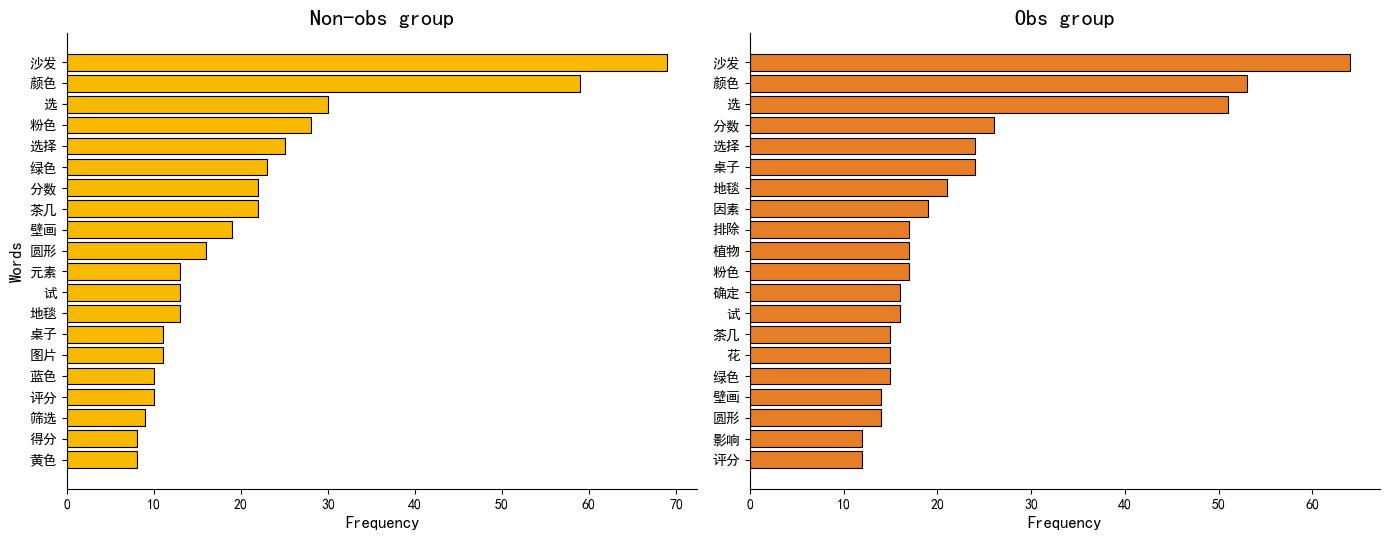

In [12]:
# ===================== obs 组 vs 非 obs 组 原始词汇分布 =====================
from collections import Counter

TOP_N_GROUP = 20

# ---------- 1. 被试 -> 组别 映射 ----------
GROUP_FILES = [
    (DATA_DIR / 'with_obs_verbal_manual_retrieve.xlsx', 'obs'),
    (DATA_DIR / 'without_obs_verbal_manual_retrieve.xlsx', 'non-obs'),
]

group_map = {}
for f, g in GROUP_FILES:
    dfx = pd.read_excel(f)
    sid_col = dfx.columns[0]
    for sid_raw in dfx[sid_col]:
        sid = normalize_sid(sid_raw)
        if sid is not None and sid in all_verbal:
            group_map[sid] = g

print(f'obs 组人数: {sum(1 for v in group_map.values() if v == "obs")}')
print(f'非 obs 组人数: {sum(1 for v in group_map.values() if v == "non-obs")}')

# ---------- 2. 分组分词统计 ----------
group_words = {'obs': [], 'non-obs': []}
for _, row in freq_df.iterrows():
    g = group_map.get(row['subject_id'])
    if g is None:
        continue
    group_words[g].extend(tokenize(clean_text(str(row['fds_text']))))

group_counter = {g: Counter(ws) for g, ws in group_words.items()}
for g in ['obs', 'non-obs']:
    print(f'{g} 组: 总词数(去停用词) {len(group_words[g])}, 不同词汇数 {len(group_counter[g])}')
    print('  Top10:', group_counter[g].most_common(10))

# ---------- 3. 中文字体 ----------
try:
    cn_font = wc_font_path  # 复用词云 cell 中已找到的字体
except NameError:
    cn_font = None
    for fp in ['C:/Windows/Fonts/simhei.ttf', 'C:/Windows/Fonts/msyh.ttc',
               'C:/Windows/Fonts/simsun.ttc', 'C:/Windows/Fonts/arialuni.ttf']:
        if Path(fp).exists():
            cn_font = fp
            break
if cn_font:
    from matplotlib import font_manager
    font_manager.fontManager.addfont(cn_font)
    cn_font_name = font_manager.FontProperties(fname=cn_font).get_name()
    plt.rcParams['font.sans-serif'] = [cn_font_name] + plt.rcParams['font.sans-serif']
    print(f'绘图使用字体: {cn_font}')
else:
    print('警告: 未找到中文字体，图中中文可能显示为方框')

# ---------- 4. 绘制两组 Top 词汇分布柱状图 ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
titles = {'non-obs': 'Non-obs group', 'obs': 'Obs group'}
colors = {'non-obs': '#F7BA00', 'obs': '#E67E28'}
for ax, g in zip(axes, ['non-obs', 'obs']):
    top = group_counter[g].most_common(TOP_N_GROUP)
    words = [w for w, _ in top][::-1]
    counts = [c for _, c in top][::-1]
    ax.barh(words, counts, color=colors[g], edgecolor='black', linewidth=0.8)
    ax.set_title(titles[g], fontsize=LABEL_SIZE)
    ax.set_xlabel('Frequency', fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 2)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('Words', fontsize=TICK_SIZE)
plt.tight_layout()
group_fds_path = OUTPUT_DIR / 'game2_obs_vs_nonobs_fds_word_dist.png'
plt.savefig(group_fds_path, dpi=DPI, bbox_inches='tight', facecolor='white')
print(f'已保存 {group_fds_path}')
plt.show()


## obs 组 vs 非 obs 组 full corpus 原始词汇分布

同样按组别划分，对两组被试的**全部 verbal content**（`subject_utterances_game1style.csv`，非仅 FDS 语句）
分词、去停用词后，分别绘制高频词汇分布柱状图（Top 20）。


obs 组(full corpus): 总词数(去停用词) 9037, 不同词汇数 1806
  Top10: [('沙发', 268), ('颜色', 210), ('分数', 164), ('选', 162), ('地毯', 157), ('选择', 138), ('茶几', 115), ('桌子', 113), ('尝试', 98), ('壁画', 91)]
non-obs 组(full corpus): 总词数(去停用词) 8713, 不同词汇数 1725
  Top10: [('沙发', 328), ('颜色', 238), ('茶几', 161), ('元素', 156), ('分数', 149), ('选', 147), ('壁画', 131), ('地毯', 116), ('选择', 116), ('试', 104)]


已保存 C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\interview_analysis_fig3\game2_obs_vs_nonobs_full_corpus_word_dist.png


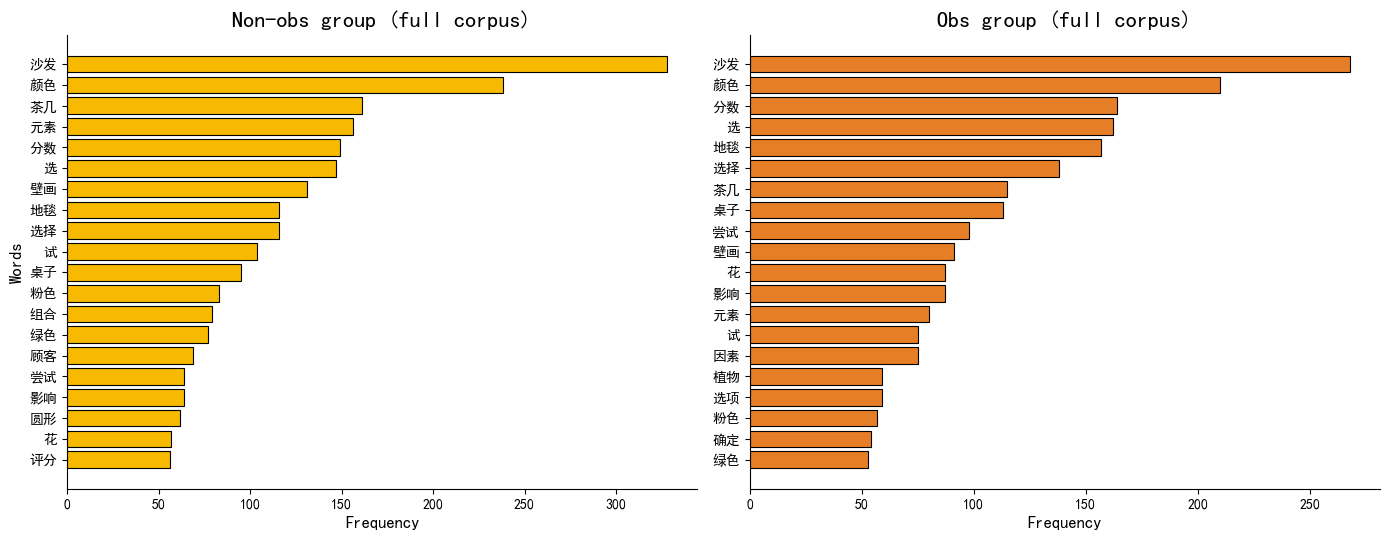

In [13]:
# ===================== obs 组 vs 非 obs 组 full corpus 原始词汇分布 =====================
from collections import Counter

TOP_N_FULL = 20

# ---------- 1. 分组分词统计（full corpus） ----------
full_group_words = {'obs': [], 'non-obs': []}
for sid, text in all_verbal.items():
    g = group_map.get(sid)
    if g is None:
        continue
    full_group_words[g].extend(tokenize(clean_text(text)))

full_group_counter = {g: Counter(ws) for g, ws in full_group_words.items()}
for g in ['obs', 'non-obs']:
    print(f'{g} 组(full corpus): 总词数(去停用词) {len(full_group_words[g])}, '
          f'不同词汇数 {len(full_group_counter[g])}')
    print('  Top10:', full_group_counter[g].most_common(10))

# ---------- 2. 绘制两组 Top 词汇分布柱状图 ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
titles = {'non-obs': 'Non-obs group (full corpus)', 'obs': 'Obs group (full corpus)'}
colors = {'non-obs': '#F7BA00', 'obs': '#E67E28'}
for ax, g in zip(axes, ['non-obs', 'obs']):
    top = full_group_counter[g].most_common(TOP_N_FULL)
    words = [w for w, _ in top][::-1]
    counts = [c for _, c in top][::-1]
    ax.barh(words, counts, color=colors[g], edgecolor='black', linewidth=0.8)
    ax.set_title(titles[g], fontsize=LABEL_SIZE)
    ax.set_xlabel('Frequency', fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 2)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('Words', fontsize=TICK_SIZE)
plt.tight_layout()
group_full_path = OUTPUT_DIR / 'game2_obs_vs_nonobs_full_corpus_word_dist.png'
plt.savefig(group_full_path, dpi=DPI, bbox_inches='tight', facecolor='white')
print(f'已保存 {group_full_path}')
plt.show()
